# DA 351 - Lab 1: Exploratory Data Analysis

### Bach Nguyen
### January 28, 2024

In this report, I will attempt to provide some insight to Airbnb properties in Columbus, Ohio by answering the following questions:
- What is the pricing range of the Airbnb properties in Columbus, Ohio?
- What are the main property/room types of those listings?
- How many of them have bus options?

## Introduction 

We will conduct some exploratory data analysis on a dataset containing the information of Airbnb listings in the Columbus area. We will do some data transformations, data cleaning first, and then we will do some filtering, creating some graphs and use a text manipulation method to answer our questions above.

For ethical considerations, there are things that we need to be careful with this dataset: the information about the property owners and the location of those properties. If somebody has bad intentions, these information can be used against the property owners and do harm to them.

The core areas of the report are:
- Pricing Range: Investigating and presenting the pricing range of Airbnb properties in Columbus, Ohio. This involves understanding the cost spectrum of available listings.

- Property/Room Types: Identifying and categorizing the main types of properties or rooms listed on Airbnb in Columbus. This aspect provides insights into the diversity of accommodation options.

- Bus Options: Assessing the availability of bus options for the Airbnb properties in Columbus. This involves determining the proximity or accessibility of these properties to bus transportation, contributing to the overall convenience for potential guests.

The report aims to offer valuable insights into these aspects, providing a comprehensive view of the Airbnb landscape in Columbus, Ohio.

## Data Exploration

### 1. Data Cleaning and Transformations

In [1]:
# importing the libraries we need
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

First of all, I will load in the data into a Pandas DataFrame

In [2]:
# reading the data
airbnb_df = pd.read_csv("data/Columbus_listings.csv")

Next, I will perform some transformation to our data as well as cleaning it.

In the first step, I will convert all available prices to floats.

In [3]:
# converting all price information columns to float types by removing special characters
def convert_price(p):
    try:
        new_price = float(p.replace('$', '').replace(',',''))
    except:
        new_price = np.nan
    return new_price

# using pandas apply to transform variables
airbnb_df["price"] = airbnb_df["price"].apply(convert_price)
airbnb_df["weekly_price"] = airbnb_df["weekly_price"].apply(convert_price)
airbnb_df["monthly_price"] = airbnb_df["monthly_price"].apply(convert_price)
airbnb_df["security_deposit"] = airbnb_df["security_deposit"].apply(convert_price)
airbnb_df["cleaning_fee"] = airbnb_df["cleaning_fee"].apply(convert_price)
airbnb_df["extra_people"] = airbnb_df["extra_people"].apply(convert_price)

In the second step, I will drop some variables and columns that will not help us for now in this lab. I will be removing variables and columns that contain URLs.

In [4]:
# dropping irrelevant columns
airbnb_df.drop(["listing_url", "thumbnail_url", "medium_url", "picture_url", "xl_picture_url", "host_url", "host_thumbnail_url", "host_picture_url"], axis=1, inplace = True)

And to make sure our data will adhere to tidy data rules, I will choose an independent variable and set it as the index. I decided to use `id` - A string variable containing the unique ID given to each property by Airbnb to identify properties individually as the independent variable.

In [5]:
# setting the index
airbnb_df.set_index(["id"], inplace = True)

### 2. Exploring the Dataset

Now we are ready to explore our dataset. First, I will create two tables displaying the top 10 highest and lowest priced properties in the dataset.

In [6]:
# displaying table for lowest priced properties
airbnb_df.sort_values(by="price", ascending=True).head(10).loc[:, ["price", "property_type", "room_type", "guests_included", "minimum_nights", "maximum_nights"]]

,price,property_type,room_type,guests_included,minimum_nights,maximum_nights
id,,,,,,
20451291,0.0,House,Private room,1,1,90
24648483,10.0,House,Entire home/apt,1,2,14
16651413,19.0,Apartment,Private room,1,1,4
497808,20.0,House,Private room,1,3,360
25158193,20.0,Apartment,Private room,1,1,30
24599205,20.0,Townhouse,Private room,3,2,1125
20942763,20.0,House,Private room,1,1,14
21120026,21.0,House,Private room,1,7,90
20076659,23.0,Apartment,Private room,1,1,5


Here, we can see that our lowest priced property goes all the way down to 0 USD for one night for a single room.

In [7]:
# displaying table for highest priced properties
airbnb_df.sort_values(by="price", ascending=False).head(10).loc[:, ["price", "property_type", "room_type", "guests_included", "minimum_nights", "maximum_nights"]]

,price,property_type,room_type,guests_included,minimum_nights,maximum_nights
id,,,,,,
27580903,1000.0,Townhouse,Entire home/apt,8,1,1125
26950163,999.0,Apartment,Entire home/apt,14,2,182
26950152,822.0,Apartment,Entire home/apt,12,2,182
26317682,822.0,Apartment,Entire home/apt,12,2,182
26317671,822.0,Apartment,Entire home/apt,12,2,182
12890097,800.0,House,Private room,1,1,1125
27553741,700.0,House,Entire home/apt,7,3,20
1541333,650.0,Bed and breakfast,Private room,2,2,1125
26950140,601.0,Apartment,Entire home/apt,12,2,182


And from this table, we can see that our highest priced property goes all the way up to 1000 USD for just one night. This is an objectively high price, but given the fact that this is a townhouse property for 8 guests, it can be considered somewhat reasonably priced. What's more notable is that there is a property listed for 800 USD for a private room for a single person for just one night.

We should keep in mind that we cannot tell the true distribution of the pricing of Airbnb listings from these two tables alone. So to get a more overall view of the pricing, we will create a histogram to see the distribution of the price for one night of the airbnbs.

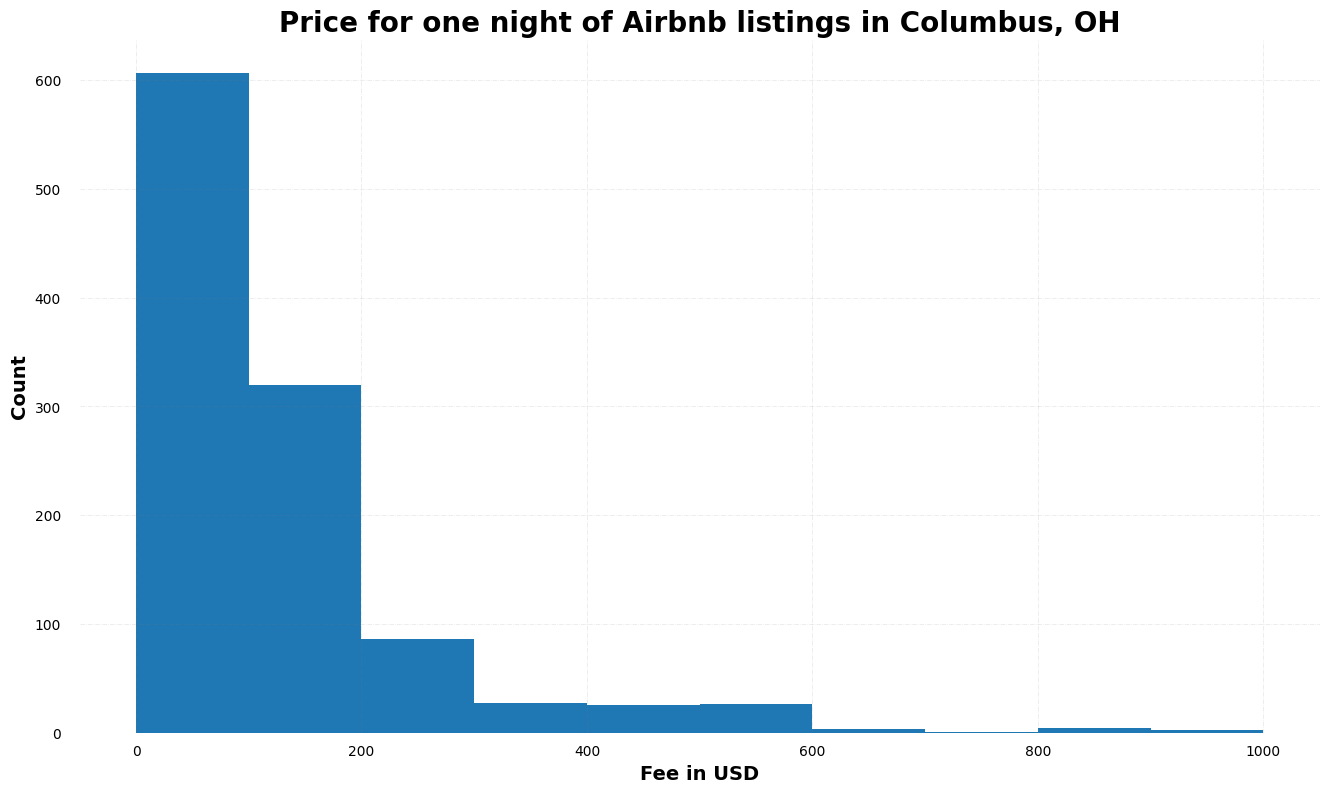

In [8]:
fig, ax = plt.subplots(figsize =(16, 9))

airbnb_df["price"].hist()

# Remove axes splines
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)
 
# Remove x, y Ticks
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
 
# Add padding between axes and labels
ax.xaxis.set_tick_params(pad = 5)
ax.yaxis.set_tick_params(pad = 10)
 
# Add x, y gridlines
ax.grid(visible = True, color ='grey',
        linestyle ='-.', linewidth = 0.5,
        alpha = 0.2)

# Add Plot Title
ax.set_title("Price for one night of Airbnb listings in Columbus, OH",
             loc ='center', fontsize=20, fontweight='bold')

plt.xlabel("Fee in USD", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')

# Display the plot
plt.show()

As expected, from this histogram, we can notice that the pricings of the majority of the listings fall between 0 - 100 USD for one night, with a huge proportion also falls between 100 - 200 USD for one night. For abnomrally highly priced properties that we got from the previous tables, they are the only few minorities and outliers in the dataset, and they don't reflect the true situation and price range of the listings.

Next, we will look at a pie chart depicting the amount and percentage of the Airbnb listings' room types.

Text(0.5, 1.0, 'Room types of Airbnb listings in Columbus, OH')

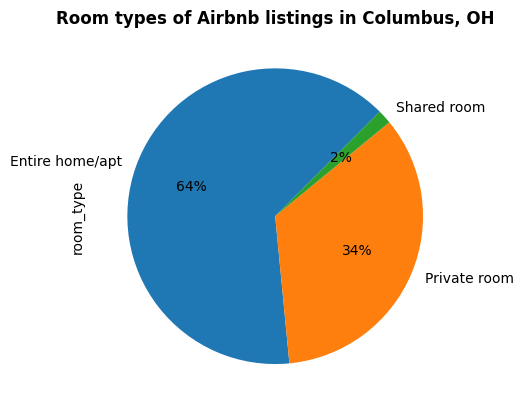

In [9]:
# pie chart depicting room types
airbnb_df["room_type"].value_counts(normalize = True).plot(
    kind='pie', autopct='%1.0f%%', startangle = 45).set_title("Room types of Airbnb listings in Columbus, OH", fontsize=12, fontweight='bold')

Here, we can see that the majority of the properties are the entire home or apartment, taking up to 64% of the listings, while private rooms only take up 34% and shared rooms taking up the least, with only a mere 2% of the total.

And now we will make a bar chart depicting the amount of the property types throughout the listings. We will begin by creating a subset that consists of the property types as well as the count for each of them.

In [10]:
property_type = airbnb_df.groupby(["property_type"], as_index = True).count().loc[:, ["name"]]
property_type.rename(columns = {"name":"count"}, inplace = True)
property_type.sort_values(by="count", ascending=False, inplace=True)
property_type.reset_index(inplace = True)

After creating the subset, we will now create the bar chart.

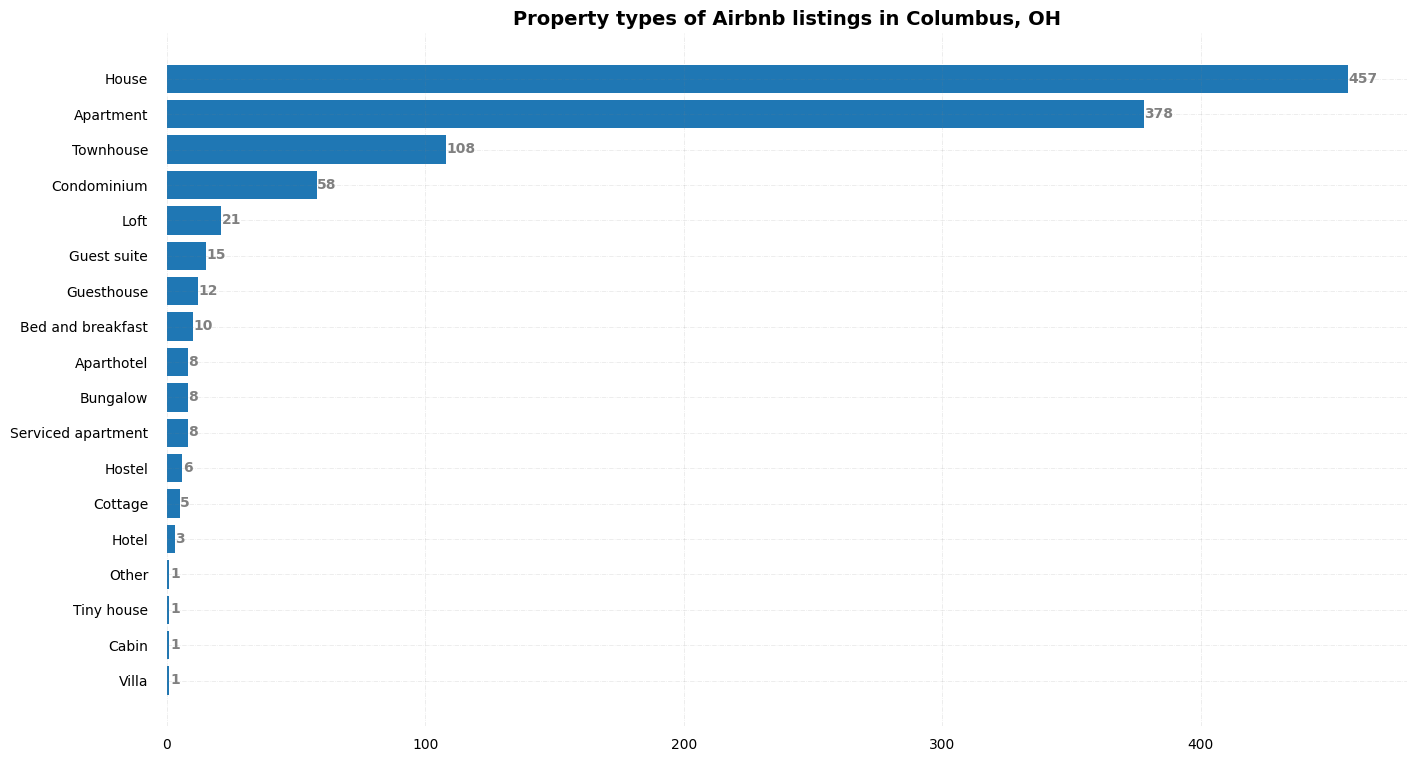

In [11]:
# Figure Size
fig, ax = plt.subplots(figsize =(16, 9))
 
# Horizontal Bar Plot
ax.barh(property_type["property_type"], property_type["count"], color = "#1F77B4")
 
# Remove axes splines
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)
 
# Remove x, y Ticks
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
 
# Add padding between axes and labels
ax.xaxis.set_tick_params(pad = 5)
ax.yaxis.set_tick_params(pad = 10)
 
# Add x, y gridlines
ax.grid(visible = True, color ='grey',
        linestyle ='-.', linewidth = 0.5,
        alpha = 0.2)
 
# Show top values
ax.invert_yaxis()
 
# Add annotation to bars
for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.5,
             str(round((i.get_width()), 2)),
             fontsize = 10, fontweight ='bold',
             color ='grey')
 
# Add Plot Title
ax.set_title("Property types of Airbnb listings in Columbus, OH",
             loc ='center', fontsize=14, fontweight='bold')
 
# Show Plot
plt.show()

From this bar chart, we can see that houses and apartments take up most if not almost the entirety of the properties will each type having 457 and 378 properties respectively. Other than those two, we can also see that townhouses take up to 108 and condominiums have 58 of them, while other property types ranges from 1 - 21 in count.

Now we will use a text manipulation method to check for whether or not the property has access to buses. We will use regex to check for all instances of the word `bus` in the `transit` column. If the number of instances are larger than 0, it means that there are accessible bus routes and stops near the property.

In [12]:
def count_bus(cell_value):
    try:
        # find all instances of "bus" using regex in the lowercase version of the cell value
        matches = re.findall(r'\bbus\b', str(cell_value).lower())

        # return the count of "bus" in the cell
        return Counter(matches)['bus']
    except:
        return 0

# creating a new column
airbnb_df["bus_availability"] = airbnb_df["transit"].apply(count_bus)

# returns bus availibility based on word count
def bus_availability_check(b):
    if b > 0:
        return "Available"
    else:
        return "Not available"

airbnb_df["bus_availability"] = airbnb_df["bus_availability"].apply(bus_availability_check)

In [13]:
# creating a subset for bus availability
bus_availability = airbnb_df.groupby(["bus_availability"], as_index = True).count().loc[:, ["name"]]
bus_availability.rename(columns = {"name":"count"}, inplace = True)
bus_availability.sort_values(by="count", ascending=False, inplace=True)
bus_availability.reset_index(inplace = True)

In [14]:
bus_availability

,bus_availability,count
0,Not available,706
1,Available,395


From this table, we can see that around 36% of the properties (395 out of 1101) is bus accessible. This means that either public transportation is not that strong in Columbus and/or most of the properties are not situated near accessible bus lines.

### 3. Conclusion
To answer the questions we set out in the beginning:
- The pricings of the majority of the listings fall between 0 - 100 USD for one night, with a huge proportion also falls between 100 - 200 USD for one night.
- The majority room type of the properties are the entire home or apartment, taking up to 64% of the listings, while houses and apartments take up most if not almost the entirety of the properties will each type having 457 and 378 respectively.
- Around 36% of the properties (395 out of 1101) is bus accessible

## Uses of Python 

Rationale for choices made in the report:

- Dropping irrelevant columns helps to focus on relevant information for analysis.
- Sorting and displaying top/bottom listings provide a quick overview of extreme cases.
- Visualization is used effectively to present insights, such as the histogram for price distribution and bar plots for property types.
- The use of functions and clearly named variables contributes to code clarity and maintainability.

Considerations:

- The code assumes a certain structure and format of the input CSV file. It would be good to include error handling or checks for missing columns to ensure robustness.
- The code is written with human readability in mind, making it accessible for others to understand and modify.
- The use of try-except blocks in functions like `convert_price` and `count_bus helps handle potential errors gracefully.

Possible improvements:

- Including comments or docstrings for functions would enhance code documentation.
- Splitting the code into functions or modular components could improve modularity and reusability.
- Unit tests could be added to ensure the reliability of functions, especially those involving data transformations.

## References

(List all works cited and consulted. Use proper APA format. Note that this assignment does not require outside sources, but all sources you draw upon must be given proper credit.)